In [1]:
from pathlib import Path
import inspect
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F


ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


from kaist_dataset.dataset import KAISTCalibrationDataset, KAISTRigCalibration, build_kaist_sequence_specs, make_kaist_dataloader

from obscalib.augmentations.config import AugmentationConfig, CalibrationEventConfig, FrameRandomizationConfig, NoiseAugmentationConfig, PerturbationMagnitudeConfig, PriorPerturbationConfig, SamplingRateAugmentationConfig, SE3NoiseConfig, VectorNoiseConfig
from obscalib.augmentations.pipeline import AugmentationPipeline
from obscalib.augmentations.profiles import TransitionProfile

from obscalib.calibration.update import CalibrationUpdater
from obscalib.config import CalibrationHeadConfig, MLPConfig, ObsCalibModelConfig, TransformerConfig, WindowingConfig
from obscalib.data.device import window_batch_to
from obscalib.data.structures import MeasurementType
from obscalib.geometry.lie import se3_log
from obscalib.geometry.processing import GeometryProcessor
from obscalib.models.obs_calib_model import ObsCalibModel
from obscalib.pipeline.window_step import WindowStep

from obscalib.observability.estimators import ObservabilityMatrixEstimator
from obscalib.observability.layout import CalibrationParameterLayout
from obscalib.observability.mappings import (
    CRLBTanhObservabilityMapper,
    CombinedObservabilityMapper,
    FlattenObservabilityMapper,
    LogConditionObservabilityMapper,
    SoftRankObservabilityMapper,
)
from obscalib.observability.numerics import ObservabilityNumericsConfig
from obscalib.observability.structures import ObservabilityResult
from obscalib.tokenization.tokenizer import Tokenizer
from obscalib.training.checkpoint import load_training_checkpoint, read_training_checkpoint, save_training_checkpoint
from obscalib.training.metrics_logger import MetricsLogger

In [ ]:
##################################################
# Experiment
##################################################

##################################################
# Experiment
##################################################
CALIBRATION_LOSS_MODE = "standard"  # "standard" or "observability_aware"
OBSERVABILITY_HOLD_WEIGHT = 1.0  # Weight of the zero-correction objective for coordinates with low observability.
OBSERVABILITY_MODE = "crlb_tanh"
OBSERVABILITY_TOKEN_MODE = "per_calibration_7d"
RUN_NAME = f"kaist_observability_crlb_tanh_7d_{CALIBRATION_LOSS_MODE}_001"
RANDOM_SEED = 12345
TRAIN_AUGMENTATION_SEED = 23456
VALIDATION_AUGMENTATION_SEED = 34567
TEST_AUGMENTATION_SEED = 45678


##################################################
# Device
##################################################

# Compute device used for model inference/training and GPU-compatible
# augmentations. Supported values here are "cpu", "cuda", or "auto".
DEVICE_NAME = "cuda"

if DEVICE_NAME == "auto":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    DEVICE = torch.device(DEVICE_NAME)

# Floating-point dtype used by the neural-network training path.
# float32 is the intended baseline for both CPU and GPU training.
MODEL_DTYPE = torch.float32


##################################################
# Dataset / windows
##################################################

# Duration [s] of one temporal observation window presented to the network.
# Each window contains all IMU and LiDAR measurements falling within this span.
WINDOW_DURATION_S = 5.0

# Temporal stride [s] between starts of consecutive dataset windows.
WINDOW_STRIDE_S = 5.0

# Safety limit on the number of samples of any individual sensor stream that
# may be included in one source window.
MAX_SAMPLES_PER_SENSOR = 700


##################################################
# DataLoader
##################################################

# Number of temporal windows processed simultaneously in one neural-network
# forward/backward pass.
BATCH_SIZE = 16

# Number of PyTorch DataLoader worker processes.
NUM_WORKERS = 0

# If True, discard the final incomplete training minibatch.
DROP_LAST_TRAIN = True


##################################################
# Training
##################################################

# Number of complete passes through the training-window dataset.
NUM_EPOCHS = 50

# Initial learning rate of the AdamW optimizer.
LEARNING_RATE = 3e-4

# AdamW decoupled weight decay.
WEIGHT_DECAY = 1e-4

# Maximum global L2 norm of model gradients.
GRADIENT_CLIP_NORM = 1.0

# Save/update the periodic "last" checkpoint every this many epochs.
CHECKPOINT_EVERY_EPOCHS = 3

# Print an intermediate training-loss line every this many minibatches.
PRINT_EVERY_BATCHES = 200


##################################################
# Model
##################################################

# Common dimensionality of the canonical measurement part of each Transformer
# token. IMU vectors use their first 3 entries and are zero-padded to 6;
# SE(3) logarithms already use all 6 [phi, rho] components.
MEASUREMENT_DIM = 6

# Base token:
#
# [measurement(6), timestamp(1), measurement_type(1)]
#
# Observability is appended later according to OBSERVABILITY_MODE.
BASE_TOKEN_INPUT_DIM = MEASUREMENT_DIM + 2

# Transformer latent dimension.
D_MODEL = 128

# Number of attention heads.
N_HEADS = 8

# Number of Transformer encoder layers.
NUM_TRANSFORMER_LAYERS = 12

# Width of the feed-forward block inside each Transformer layer.
DIM_FEEDFORWARD = 512

# Number of learned global summary tokens.
NUM_SUMMARY_TOKENS = 4

# Transformer dropout probability.
TRANSFORMER_DROPOUT = 0.1

# Hidden dimensions of the shared post-Transformer MLP.
MLP_HIDDEN_DIMS = (256, 128)

# Shared feature dimension supplied to all calibration heads.
SHARED_FEATURE_DIM = 128

# Hidden dimensions of each calibration-specific head.
HEAD_HIDDEN_DIMS = (128, 64)

# Calibration context:
#
# [phi_x, phi_y, phi_z, rho_x, rho_y, rho_z, tau]
CALIBRATION_CONTEXT_DIM = 7


##################################################
# Observability
##################################################

# Network-facing observability representation.
#
# Supported values:
#     "none"
#     "crlb_tanh"
#     "matrix"
#     "soft_rank"
#     "log_condition"
#     "combined"
OBSERVABILITY_MODE = "crlb_tanh"

# Exact concatenation order when OBSERVABILITY_MODE == "combined".
OBSERVABILITY_COMPONENT_ORDER = (
    "crlb_tanh",
    "matrix",
    "soft_rank",
    "log_condition",
)

# Use compiled gyroscope/LiDAR observability kernels.
USE_NJIT_OBSERVABILITY = True

# Strict numerical tolerance used by trajectory/nuisance projection.
PROJECTION_NUMERICAL_TOLERANCE = 1e-10

# Practical threshold used when inverting calibration singular values for
# CRLB-like quantities. Weak near-null modes are treated as unobservable.
CRLB_OBSERVABILITY_TOLERANCE = 1e-5

# A coordinate is declared completely unobservable only when essentially its
# complete basis direction lies in the selected nullspace.
COORDINATE_NULLSPACE_TOLERANCE = 1e-8

# Characteristic uncertainty scales for CRLBTanh.
CRLB_TANH_ROTATION_ALPHA_RAD = np.deg2rad(5.0)
CRLB_TANH_TRANSLATION_ALPHA_M = 0.05
CRLB_TANH_TIME_ALPHA_S = 0.015

# Normalization of the full Fisher matrix before flattening.
# Supported values: "none", "max_abs", "fro".
MATRIX_NORMALIZATION = "none"

# Soft-rank parameters operating on relative singular values.
SOFT_RANK_THRESHOLD = 1e-5
SOFT_RANK_TEMPERATURE = 2e-6

# log10(condition number) normalization range.
LOG_CONDITION_MAX_DECADES = 12.0

# LiDAR stream used to construct the local nominal trajectory for observability.
REFERENCE_LIDAR_STREAM_KEY = "lidar"


##################################################
# Loss normalization
##################################################

# Characteristic rotation error [rad].
ROTATION_LOSS_SCALE_RAD = np.deg2rad(5.0)

# Characteristic translational tangent error [m].
TRANSLATION_LOSS_SCALE_M = 0.05

# Characteristic temporal calibration error [s].
TIME_OFFSET_LOSS_SCALE_S = 0.015

# Characteristic event-time scale [s].
CHANGE_TIME_LOSS_SCALE_S = WINDOW_DURATION_S

# Relative loss weights.
ROTATION_LOSS_WEIGHT = 2.0
TRANSLATION_LOSS_WEIGHT = 1.0
TIME_OFFSET_LOSS_WEIGHT = 1.0
CHANGE_EVENT_LOSS_WEIGHT = 0.1
CHANGE_TIME_LOSS_WEIGHT = 0.1


##################################################
# Learning-rate scheduler
##################################################

LR_REDUCTION_FACTOR = 0.5
LR_PATIENCE_EPOCHS = 5


##################################################
# Checkpoint resume
##################################################

RESUME_CHECKPOINT = None

# Example:
# RESUME_CHECKPOINT = ROOT / "runs" / RUN_NAME / "last.pt"


##################################################
# Reproducibility initialization
##################################################

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)

Device: cuda
Batch size: 16


In [3]:
KAIST_DATASET_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
LIDAR_POSE_ROOT = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset")


##################################################
# Sequence-level split
##################################################

TRAIN_NAMES = [
    "Urban08",
    "Urban12",
    "Urban13",
    "Urban14",
    "Urban15",
    "Urban16",
]

VAL_NAMES = [
    "Urban26",
    "Urban28",
]

TEST_NAMES = [
    "Urban38",
    "Urban39",
]


ALL_SEQUENCE_NAMES = TRAIN_NAMES + VAL_NAMES + TEST_NAMES

if len(ALL_SEQUENCE_NAMES) != len(set(ALL_SEQUENCE_NAMES)):
    raise ValueError("Train, validation, and test sequence sets overlap.")

print("train:", TRAIN_NAMES)
print("validation:", VAL_NAMES)
print("test:", TEST_NAMES)

train: ['Urban08', 'Urban12', 'Urban13', 'Urban14', 'Urban15', 'Urban16']
validation: ['Urban26', 'Urban28']
test: ['Urban38', 'Urban39']


In [4]:
##################################################
# KAIST body-frame calibration
##################################################

T_B_L = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933, 0.707457,  1.90953],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_I_B = np.array([
    [1.0, 0.0, 0.0, -0.07],
    [0.0, 1.0, 0.0,  0.0],
    [0.0, 0.0, 1.0,  1.7],
    [0.0, 0.0, 0.0,  1.0],
], dtype=float)

T_B_I = np.linalg.inv(T_I_B)


rig_calibration = KAISTRigCalibration(
    T_B_I=T_B_I,
    T_B_L=T_B_L,
    tau_imu_s=0.0,
    tau_lidar_s=0.0,
)


windowing_config = WindowingConfig(
    window_duration_s=WINDOW_DURATION_S,
    window_stride_s=WINDOW_STRIDE_S,
    max_samples_per_sensor=MAX_SAMPLES_PER_SENSOR,
)

In [5]:
all_specs = build_kaist_sequence_specs(
    sequence_names=ALL_SEQUENCE_NAMES,
    kaist_dataset_root=KAIST_DATASET_ROOT,
    lidar_pose_root=LIDAR_POSE_ROOT,
)

spec_by_name = {
    spec.name: spec
    for spec in all_specs
}


train_dataset = KAISTCalibrationDataset(
    [spec_by_name[name] for name in TRAIN_NAMES],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)

val_dataset = KAISTCalibrationDataset(
    [spec_by_name[name] for name in VAL_NAMES],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)

test_dataset = KAISTCalibrationDataset(
    [spec_by_name[name] for name in TEST_NAMES],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)


print(train_dataset.summary())
print()
print(val_dataset.summary())
print()
print(test_dataset.summary())

KAISTCalibrationDataset: 2005 windows from 6 sequences
approximate tensor storage: 37.4 MiB
  Urban08: windows=59, duration=297.8s, IMU=30800, LiDAR=2952
  Urban12: windows=473, duration=2478.6s, IMU=249198, LiDAR=23222
  Urban13: windows=223, duration=1446.5s, IMU=145492, LiDAR=10536
  Urban14: windows=286, duration=1737.0s, IMU=174681, LiDAR=13638
  Urban15: windows=184, duration=1034.3s, IMU=104795, LiDAR=9011
  Urban16: windows=780, duration=4458.2s, IMU=449215, LiDAR=37703

KAISTCalibrationDataset: 417 windows from 2 sequences
approximate tensor storage: 7.8 MiB
  Urban26: windows=94, duration=567.0s, IMU=58371, LiDAR=4553
  Urban28: windows=323, duration=1958.6s, IMU=197456, LiDAR=15651

KAISTCalibrationDataset: 699 windows from 2 sequences
approximate tensor storage: 13.1 MiB
  Urban38: windows=349, duration=2147.3s, IMU=216225, LiDAR=17005
  Urban39: windows=350, duration=1856.3s, IMU=186682, LiDAR=17195


In [6]:
train_shuffle_generator = torch.Generator().manual_seed(RANDOM_SEED)


train_loader = make_kaist_dataloader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    num_workers=NUM_WORKERS,
    generator=train_shuffle_generator,
)

val_loader = make_kaist_dataloader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)

test_loader = make_kaist_dataloader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)


print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 125
validation batches: 27
test batches: 44


In [7]:
augmentation_config = AugmentationConfig(
    sampling_rate=SamplingRateAugmentationConfig(
        enabled=True,
        minimum_imu_frequency_hz=40.0,
        minimum_lidar_frequency_hz=5.0,
        imu_probability=0.8,
        lidar_probability=0.5,
    ),

    frame_randomization=FrameRandomizationConfig(
        enabled=True,
    ),

    prior_perturbation=PriorPerturbationConfig(
        enabled=True,
        probability=0.8,
        rotation=PerturbationMagnitudeConfig(
            maximum=np.deg2rad(15.0),
        ),
        translation=PerturbationMagnitudeConfig(
            maximum=0.15,
        ),
        time_offset=PerturbationMagnitudeConfig(
            maximum=0.03,
        ),
    ),

    calibration_event=CalibrationEventConfig(
        enabled=True,
        event_probability=0.5,

        rotation_probability=0.8,
        translation_probability=0.7,
        time_offset_probability=0.5,

        rotation=PerturbationMagnitudeConfig(
            maximum=np.deg2rad(10.0),
        ),
        translation=PerturbationMagnitudeConfig(
            maximum=0.10,
        ),
        time_offset=PerturbationMagnitudeConfig(
            maximum=0.0095,
        ),

        profile_weights={
            TransitionProfile.STEP: 1.0,
            TransitionProfile.LINEAR: 1.0,
            TransitionProfile.SMOOTHSTEP: 1.0,
        },

        minimum_transition_duration_s=0.5,
        maximum_transition_duration_s=3.0,

        minimum_pre_event_fraction=0.2,
        minimum_post_event_fraction=0.2,
    ),

    noise=NoiseAugmentationConfig(
        enabled=True,

        vector_by_type={
            MeasurementType.IMU_GYROSCOPE: VectorNoiseConfig(
                gaussian_std=0.01,
                window_bias_std=0.003,
            ),
            MeasurementType.IMU_ACCELEROMETER: VectorNoiseConfig(
                gaussian_std=0.08,
                window_bias_std=0.03,
            ),
        },

        se3_by_type={
            MeasurementType.LIDAR_POSE: SE3NoiseConfig(
                rotation_std=np.deg2rad(0.15),
                translation_std=0.01,
            ),
        },
    ),
)


augmentation_pipeline = AugmentationPipeline(
    augmentation_config
)

In [8]:
##################################################
# Observability feature mapping
##################################################

SUPPORTED_OBSERVABILITY_COMPONENTS = {
    "crlb_tanh",
    "matrix",
    "soft_rank",
    "log_condition",
}

if OBSERVABILITY_MODE != "none" and OBSERVABILITY_MODE != "combined" and OBSERVABILITY_MODE not in SUPPORTED_OBSERVABILITY_COMPONENTS:
    raise ValueError(f"Unknown OBSERVABILITY_MODE={OBSERVABILITY_MODE!r}.")

if OBSERVABILITY_MODE == "combined":
    if not OBSERVABILITY_COMPONENT_ORDER:
        raise ValueError("OBSERVABILITY_COMPONENT_ORDER must be non-empty in combined mode.")

    unknown_components = set(OBSERVABILITY_COMPONENT_ORDER) - SUPPORTED_OBSERVABILITY_COMPONENTS

    if unknown_components:
        raise ValueError(f"Unknown combined observability components: {sorted(unknown_components)}.")


def observability_component_order() -> tuple[str, ...]:
    """Return the exact feature-component order used by the network."""

    if OBSERVABILITY_MODE == "none":
        return ()

    if OBSERVABILITY_MODE == "combined":
        return tuple(OBSERVABILITY_COMPONENT_ORDER)

    return (OBSERVABILITY_MODE,)


def observability_feature_dimension(calibration_dimension: int) -> int:
    """Return d_observability for the selected mapper configuration."""

    dimensions = {
        "crlb_tanh": calibration_dimension,
        "matrix": calibration_dimension * calibration_dimension,
        "soft_rank": 1,
        "log_condition": 1,
    }

    return sum(dimensions[component] for component in observability_component_order())


##################################################
# Network-facing observability mapper
##################################################

CRLB_TANH_ALPHA = (
    CRLB_TANH_ROTATION_ALPHA_RAD,
    CRLB_TANH_ROTATION_ALPHA_RAD,
    CRLB_TANH_ROTATION_ALPHA_RAD,
    CRLB_TANH_TRANSLATION_ALPHA_M,
    CRLB_TANH_TRANSLATION_ALPHA_M,
    CRLB_TANH_TRANSLATION_ALPHA_M,
    CRLB_TANH_TIME_ALPHA_S,
)


def build_observability_component_mapper(
    component: str,
):
    """Build one configured observability feature mapper."""

    if component == "crlb_tanh":
        return CRLBTanhObservabilityMapper(
            alpha=CRLB_TANH_ALPHA,
            numerics=observability_numerics,
            relative_tolerance=CRLB_OBSERVABILITY_TOLERANCE,
            nullspace_tolerance=COORDINATE_NULLSPACE_TOLERANCE,
        )

    if component == "matrix":
        return FlattenObservabilityMapper(
            numerics=observability_numerics,
        )

    if component == "soft_rank":
        return SoftRankObservabilityMapper(
            threshold=SOFT_RANK_THRESHOLD,
            temperature=SOFT_RANK_TEMPERATURE,
            numerics=observability_numerics,
        )

    if component == "log_condition":
        return LogConditionObservabilityMapper(
            numerics=observability_numerics,
        )

    raise ValueError(
        f"Unknown observability component {component!r}."
    )


def build_observability_mapper():
    """Build the configured network-facing observability representation."""

    component_order = observability_component_order()

    if not component_order:
        return None

    component_mappers = [
        build_observability_component_mapper(
            component
        )
        for component in component_order
    ]

    if len(component_mappers) == 1:
        return component_mappers[0]

    return CombinedObservabilityMapper(
        component_mappers
    )


In [ ]:
##################################################
# Scientific observability setup
##################################################

CALIBRATION_KEYS = (
    "imu",
    "lidar",
)

calibration_layout = CalibrationParameterLayout.from_calibration_keys(
    CALIBRATION_KEYS
)

OBSERVABILITY_FEATURE_DIM = observability_feature_dimension(calibration_layout.total_dimension)

##################################################
# Token dimensions
##################################################
BASE_TOKEN_INPUT_DIM = MEASUREMENT_DIM + 2
CALIBRATION_CONTEXT_DIM = 7
OBSERVABILITY_TOKEN_FEATURE_DIM = 0 if OBSERVABILITY_MODE == "none" else CALIBRATION_CONTEXT_DIM
TOKEN_INPUT_DIM = BASE_TOKEN_INPUT_DIM + OBSERVABILITY_TOKEN_FEATURE_DIM

if OBSERVABILITY_TOKEN_MODE != "per_calibration_7d":
    raise ValueError(f"Unsupported OBSERVABILITY_TOKEN_MODE={OBSERVABILITY_TOKEN_MODE!r}.")

if OBSERVABILITY_MODE not in {"none", "crlb_tanh"}:
    raise ValueError("The per-calibration 7D token path currently supports OBSERVABILITY_MODE='crlb_tanh' or 'none'.")


##################################################
# Empirical KAIST residual covariance
##################################################

# Gyroscope covariance is currently used as one constant factor covariance.
# It is measured per angular-velocity sample, while the gyroscope residual is
# integrated over an interval, so this remains an explicit approximation until
# covariance propagation is moved inside the factor.
GYRO_MEASUREMENT_COVARIANCE = torch.tensor(
    [
        [2.96367932e-06, -1.94438078e-07, -4.83643437e-07],
        [-1.94438078e-07, 1.89162212e-06, 1.09062693e-07],
        [-4.83643437e-07, 1.09062693e-07, 1.88843506e-06],
    ],
    dtype=torch.float64,
)

ACCEL_MEASUREMENT_COVARIANCE = torch.tensor(
    [
        [4.85003041e-03, -9.25262862e-05, 2.14219676e-04],
        [-9.25262862e-05, 1.51980006e-03, -1.13182999e-03],
        [2.14219676e-04, -1.13182999e-03, 2.29777687e-03],
    ],
    dtype=torch.float64,
)

LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE = torch.tensor(
    [
        [1.10442767e-05, 9.46809587e-07, 3.78536515e-06],
        [9.46809587e-07, 3.35041997e-05, 1.90008728e-06],
        [3.78536515e-06, 1.90008728e-06, 1.10553483e-05],
    ],
    dtype=torch.float64,
)

LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE = torch.tensor(
    [
        [0.00843466, 0.00266052, 0.00702046],
        [0.00266052, 0.01444850, 0.00225705],
        [0.00702046, 0.00225705, 0.00704268],
    ],
    dtype=torch.float64,
)

LIDAR_SCAN_TO_MAP_COVARIANCE = torch.zeros(
    (6, 6),
    dtype=torch.float64,
)

LIDAR_SCAN_TO_MAP_COVARIANCE[:3, :3] = LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE
LIDAR_SCAN_TO_MAP_COVARIANCE[3:, 3:] = LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE

# Relative scan-to-scan LiDAR residual covariance is approximated by the sum
# of two independent scan-to-map endpoint covariances.
LIDAR_RELATIVE_RESIDUAL_COVARIANCE = (
    2.0
    * LIDAR_SCAN_TO_MAP_COVARIANCE
)

residual_covariance_by_stream = {
    "gyro": GYRO_MEASUREMENT_COVARIANCE,
    "accel": ACCEL_MEASUREMENT_COVARIANCE,
    "lidar": LIDAR_RELATIVE_RESIDUAL_COVARIANCE,
}

GRAVITY_WORLD = torch.tensor(
    [0.0, 0.0, 9.81],
    dtype=torch.float64,
)

gyro_bias_by_calibration_key = {
    "imu": torch.zeros(
        3,
        dtype=torch.float64,
    ),
}

observability_numerics = ObservabilityNumericsConfig(
    relative_tolerance=PROJECTION_NUMERICAL_TOLERANCE,
    parameter_scales=None,
)


def relative_lidar_body_trajectory_provider(measurements, metadata, calibration, reference_timebase):
    """
    Construct one local nominal body trajectory from the selected relative LiDAR stream.

    This trajectory is only the observability linearization point. It starts at
    identity, chains measured relative LiDAR motion through the current T_B_L,
    and never acts as a calibration target or ground truth.
    """

    stream_key = reference_timebase.stream_key

    if stream_key != REFERENCE_LIDAR_STREAM_KEY:
        raise ValueError(f"Expected reference stream {REFERENCE_LIDAR_STREAM_KEY!r}, got {stream_key!r}.")

    if stream_key not in measurements or stream_key not in metadata:
        raise KeyError(f"Missing reference LiDAR stream {stream_key!r}.")

    stream = measurements[stream_key]

    if stream.interval_start_timestamps is None:
        raise ValueError("Reference LiDAR stream must carry interval_start_timestamps.")

    calibration_key = metadata[stream_key].calibration_key
    T_B_L = calibration[calibration_key].transform

    if T_B_L.ndim == 3:
        if T_B_L.shape[0] != 1:
            raise ValueError("Unbatched trajectory provider expects one calibration state.")

        T_B_L = T_B_L[0]

    T_B_L = T_B_L.to(
        device="cpu",
        dtype=torch.float64,
    )

    T_L_B = torch.linalg.inv(
        T_B_L
    )

    relative_lidar_poses = stream.values.to(
        device="cpu",
        dtype=torch.float64,
    )

    interval_starts = stream.interval_start_timestamps.to(
        device="cpu",
        dtype=torch.float64,
    )

    interval_ends = stream.timestamps.to(
        device="cpu",
        dtype=torch.float64,
    )

    reference_timestamps = reference_timebase.timestamps.to(
        device="cpu",
        dtype=torch.float64,
    )

    if relative_lidar_poses.shape[0] == 0:
        raise ValueError("Reference LiDAR stream is empty.")

    poses_by_time = {}

    current_pose = torch.eye(
        4,
        dtype=torch.float64,
    )

    current_end_time = None

    for interval_index in range(relative_lidar_poses.shape[0]):
        start_time = float(
            interval_starts[interval_index].item()
        )

        end_time = float(
            interval_ends[interval_index].item()
        )

        if current_end_time is None or abs(start_time - current_end_time) > 1e-6:
            start_pose = current_pose
        else:
            start_pose = current_pose

        poses_by_time[start_time] = start_pose

        relative_body_motion = (
            T_B_L
            @ relative_lidar_poses[interval_index]
            @ T_L_B
        )

        current_pose = (
            start_pose
            @ relative_body_motion
        )

        poses_by_time[end_time] = current_pose
        current_end_time = end_time

    available_times = np.asarray(
        sorted(poses_by_time),
        dtype=float,
    )

    trajectory_poses = []

    for timestamp in reference_timestamps:
        query_time = float(
            timestamp.item()
        )

        nearest_index = int(
            np.argmin(
                np.abs(
                    available_times
                    - query_time
                )
            )
        )

        nearest_time = float(
            available_times[nearest_index]
        )

        if abs(nearest_time - query_time) > 1e-6:
            raise ValueError(
                f"Could not construct nominal pose at reference timestamp {query_time:.9f}."
            )

        trajectory_poses.append(
            poses_by_time[nearest_time]
        )

    return torch.stack(
        trajectory_poses,
        dim=0,
    )


##################################################
# Estimator / mapper construction
##################################################

if OBSERVABILITY_MODE == "none":
    observability_estimator = None
    observability_mapper = None

else:
    estimator_signature = inspect.signature(
        ObservabilityMatrixEstimator.__init__
    )

    estimator_kwargs = {
        "calibration_layout": calibration_layout,
        "trajectory_provider": relative_lidar_body_trajectory_provider,
        "residual_covariance_by_stream": residual_covariance_by_stream,
    }

    optional_estimator_kwargs = {
        "gravity_world": GRAVITY_WORLD,
        "gyro_bias_by_calibration_key": gyro_bias_by_calibration_key,
        "numerics": observability_numerics,
        "njit": USE_NJIT_OBSERVABILITY,
        "reference_stream_key": REFERENCE_LIDAR_STREAM_KEY,
    }

    for argument_name, argument_value in optional_estimator_kwargs.items():
        if argument_name in estimator_signature.parameters:
            estimator_kwargs[argument_name] = argument_value

    missing_required_arguments = [
        name
        for name, parameter
        in estimator_signature.parameters.items()
        if name != "self"
        and parameter.kind in {
            inspect.Parameter.POSITIONAL_ONLY,
            inspect.Parameter.POSITIONAL_OR_KEYWORD,
            inspect.Parameter.KEYWORD_ONLY,
        }
        and parameter.default is inspect.Parameter.empty
        and name not in estimator_kwargs
    ]

    if missing_required_arguments:
        raise RuntimeError(
            "The installed ObservabilityMatrixEstimator has required constructor "
            f"arguments not configured by this notebook: {missing_required_arguments}. "
            f"Current signature: {estimator_signature}"
        )

    observability_estimator = ObservabilityMatrixEstimator(
        **estimator_kwargs
    )

    observability_mapper = build_observability_mapper()


print("Observability mode:", OBSERVABILITY_MODE)
print("Observability token mode:", OBSERVABILITY_TOKEN_MODE)
print("Calibration dimension:", calibration_layout.total_dimension)
print("Global observability feature dimension:", OBSERVABILITY_FEATURE_DIM)
print("Per-calibration token observability dimension:", OBSERVABILITY_TOKEN_FEATURE_DIM)
print("Transformer token input dimension:", TOKEN_INPUT_DIM)
print("Calibration loss mode:", CALIBRATION_LOSS_MODE)
print("Observability hold weight:", OBSERVABILITY_HOLD_WEIGHT)
print("NJIT observability:", USE_NJIT_OBSERVABILITY if OBSERVABILITY_MODE != "none" else False)

Observability mode: crlb_tanh
Observability component order: ('crlb_tanh',)
Calibration dimension: 14
Observability feature dimension: 14
Transformer token input dimension: 22
NJIT observability: True


In [10]:
model_config = ObsCalibModelConfig(
    transformer=TransformerConfig(
        input_dim=TOKEN_INPUT_DIM,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_layers=NUM_TRANSFORMER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=TRANSFORMER_DROPOUT,
        activation="gelu",
        num_summary_tokens=NUM_SUMMARY_TOKENS,
    ),

    mlp=MLPConfig(
        hidden_dims=MLP_HIDDEN_DIMS,
        output_dim=SHARED_FEATURE_DIM,
        activation="gelu",
        dropout=0.1,
    ),

    calibration_head=CalibrationHeadConfig(
        calibration_context_dim=CALIBRATION_CONTEXT_DIM,
        hidden_dims=HEAD_HIDDEN_DIMS,
        activation="gelu",
        dropout=0.1,
    ),

    head_keys=(
        "imu",
        "lidar",
    ),
)


model = ObsCalibModel(
    model_config
).to(
    device=DEVICE,
    dtype=MODEL_DTYPE,
)


geometry_processor = GeometryProcessor()

tokenizer = Tokenizer(
    measurement_dim=MEASUREMENT_DIM,
)

calibration_updater = CalibrationUpdater()


window_step = WindowStep(
    geometry_processor=geometry_processor,
    tokenizer=tokenizer,
    model=model,
    calibration_updater=calibration_updater,
    observability_estimator=observability_estimator,
    observability_mapper=observability_mapper,
)


num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

num_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Parameters:", num_parameters)
print("Trainable parameters:", num_trainable_parameters)

Parameters: 2615954
Trainable parameters: 2615954


In [ ]:
##################################################
# Experiment snapshot stored inside checkpoints
##################################################

EXPERIMENT_SNAPSHOT = {
    "schema_version": 1,

    # Scientific observability and NN feature representation.
    "observability_config": {
        "mode": OBSERVABILITY_MODE,
        "component_order": observability_component_order(),
        "feature_dim": OBSERVABILITY_FEATURE_DIM,
        "token_feature_mode": OBSERVABILITY_TOKEN_MODE,
        "token_feature_dim": OBSERVABILITY_TOKEN_FEATURE_DIM,
        "use_njit": USE_NJIT_OBSERVABILITY,
        "projection_numerical_tolerance": PROJECTION_NUMERICAL_TOLERANCE,
        "crlb_observability_tolerance": CRLB_OBSERVABILITY_TOLERANCE,
        "coordinate_nullspace_tolerance": COORDINATE_NULLSPACE_TOLERANCE,
        "crlb_rotation_alpha_rad": CRLB_TANH_ROTATION_ALPHA_RAD,
        "crlb_translation_alpha_m": CRLB_TANH_TRANSLATION_ALPHA_M,
        "crlb_time_alpha_s": CRLB_TANH_TIME_ALPHA_S,
        "matrix_normalization": MATRIX_NORMALIZATION,
        "soft_rank_threshold": SOFT_RANK_THRESHOLD,
        "soft_rank_temperature": SOFT_RANK_TEMPERATURE,
        "log_condition_max_decades": LOG_CONDITION_MAX_DECADES,
        "reference_lidar_stream_key": REFERENCE_LIDAR_STREAM_KEY,
    },

    # Exact model architecture required to reconstruct ObsCalibModel.
    "model_config": model_config,

    # Tokenizer configuration.
    "measurement_dim": MEASUREMENT_DIM,

    # Dataset window construction.
    "windowing_config": windowing_config,

    # Nominal KAIST sensor-to-body calibration.
    "rig_calibration": rig_calibration,

    # Synthetic training distribution.
    "augmentation_config": augmentation_config,

    # Training loss definition.
    "loss_config": {
        "calibration_loss_mode": CALIBRATION_LOSS_MODE,
        "observability_hold_weight": OBSERVABILITY_HOLD_WEIGHT,
        "rotation_loss_scale_rad": ROTATION_LOSS_SCALE_RAD,
        "translation_loss_scale_m": TRANSLATION_LOSS_SCALE_M,
        "time_offset_loss_scale_s": TIME_OFFSET_LOSS_SCALE_S,
        "change_time_loss_scale_s": CHANGE_TIME_LOSS_SCALE_S,
        "rotation_loss_weight": ROTATION_LOSS_WEIGHT,
        "translation_loss_weight": TRANSLATION_LOSS_WEIGHT,
        "time_offset_loss_weight": TIME_OFFSET_LOSS_WEIGHT,
        "change_event_loss_weight": CHANGE_EVENT_LOSS_WEIGHT,
        "change_time_loss_weight": CHANGE_TIME_LOSS_WEIGHT,
    },

    # Dataset split.
    "sequence_split": {
        "train": tuple(TRAIN_NAMES),
        "validation": tuple(VAL_NAMES),
        "test": tuple(TEST_NAMES),
    },

    # Training provenance.
    "training_config": {
        "run_name": RUN_NAME,
        "model_dtype": str(MODEL_DTYPE),
        "random_seed": RANDOM_SEED,
        "train_augmentation_seed": TRAIN_AUGMENTATION_SEED,
        "validation_augmentation_seed": VALIDATION_AUGMENTATION_SEED,
        "test_augmentation_seed": TEST_AUGMENTATION_SEED,
    },
}

In [12]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_REDUCTION_FACTOR,
    patience=LR_PATIENCE_EPOCHS,
)

In [ ]:
def _observability_aware_smooth_l1_loss(prediction, target, observability, scale):
    """Blend the normal correction target with a zero-correction target using coordinate-wise observability."""

    prediction_scaled = prediction / scale
    target_scaled = target / scale
    zero_scaled = torch.zeros_like(prediction_scaled)

    target_loss = F.smooth_l1_loss(prediction_scaled, target_scaled, reduction="none")
    hold_loss = F.smooth_l1_loss(prediction_scaled, zero_scaled, reduction="none")

    weighted_loss = observability * target_loss + OBSERVABILITY_HOLD_WEIGHT * (1.0 - observability) * hold_loss

    return weighted_loss.mean()


def compute_training_loss(window, model_output, observability=None):
    """Compute normalized calibration and auxiliary losses for all model heads with selectable standard or observability-aware correction losses."""

    if window.targets is None:
        raise ValueError("Training window has no targets.")

    total_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)
    metrics = {}
    num_heads = 0

    for calibration_key, prediction in model_output.predictions.items():
        if calibration_key not in window.targets:
            raise KeyError(f"Missing training target for calibration head {calibration_key!r}.")

        target = window.targets[calibration_key]
        current_state = window.current_calibration[calibration_key]

        if target.next_transform is None or target.next_time_offset is None:
            raise ValueError(f"Calibration target {calibration_key!r} does not contain final calibration state.")

        ##################################################
        # Geometric correction target
        ##################################################
        target_delta_transform = target.next_transform @ torch.linalg.inv(current_state.transform)
        target_delta_xi = se3_log(target_delta_transform)
        target_delta_tau = target.next_time_offset - current_state.time_offset

        ##################################################
        # Primary calibration losses
        ##################################################
        if CALIBRATION_LOSS_MODE == "standard":
            rotation_loss = F.smooth_l1_loss(prediction.delta_xi[:, :3] / ROTATION_LOSS_SCALE_RAD, target_delta_xi[:, :3] / ROTATION_LOSS_SCALE_RAD)
            translation_loss = F.smooth_l1_loss(prediction.delta_xi[:, 3:] / TRANSLATION_LOSS_SCALE_M, target_delta_xi[:, 3:] / TRANSLATION_LOSS_SCALE_M)
            time_offset_loss = F.smooth_l1_loss(prediction.delta_tau / TIME_OFFSET_LOSS_SCALE_S, target_delta_tau / TIME_OFFSET_LOSS_SCALE_S)
        elif CALIBRATION_LOSS_MODE == "observability_aware":
            if observability is None:
                raise ValueError("Observability-aware loss requires an ObservabilityResult.")
            if observability.calibration_features is None:
                raise ValueError("Observability-aware loss requires calibration-local observability features.")
            if calibration_key not in observability.calibration_features:
                raise KeyError(f"Observability features are missing calibration key {calibration_key!r}.")

            calibration_observability = observability.calibration_features[calibration_key]

            if calibration_observability.shape != (prediction.delta_xi.shape[0], 7):
                raise ValueError(f"Observability features for calibration key {calibration_key!r} must have shape [B, 7], got {tuple(calibration_observability.shape)}.")

            calibration_observability = calibration_observability.detach().to(device=prediction.delta_xi.device, dtype=prediction.delta_xi.dtype)

            if not torch.isfinite(calibration_observability).all():
                raise ValueError(f"Observability features for calibration key {calibration_key!r} contain non-finite values.")

            if torch.any(calibration_observability < 0.0) or torch.any(calibration_observability > 1.0):
                raise ValueError(f"Observability features for calibration key {calibration_key!r} must lie in [0, 1].")

            observability_phi = calibration_observability[:, :3]
            observability_rho = calibration_observability[:, 3:6]
            observability_tau = calibration_observability[:, 6:7]

            rotation_loss = _observability_aware_smooth_l1_loss(prediction.delta_xi[:, :3], target_delta_xi[:, :3], observability_phi, ROTATION_LOSS_SCALE_RAD)
            translation_loss = _observability_aware_smooth_l1_loss(prediction.delta_xi[:, 3:], target_delta_xi[:, 3:], observability_rho, TRANSLATION_LOSS_SCALE_M)
            time_offset_loss = _observability_aware_smooth_l1_loss(prediction.delta_tau, target_delta_tau, observability_tau, TIME_OFFSET_LOSS_SCALE_S)

            metrics[f"{calibration_key}/observability_phi_mean"] = observability_phi.mean().detach().item()
            metrics[f"{calibration_key}/observability_rho_mean"] = observability_rho.mean().detach().item()
            metrics[f"{calibration_key}/observability_tau_mean"] = observability_tau.mean().detach().item()
        else:
            raise ValueError(f"Unknown CALIBRATION_LOSS_MODE={CALIBRATION_LOSS_MODE!r}.")

        ##################################################
        # Auxiliary event losses
        ##################################################
        if target.change_label is None:
            change_event_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)
            change_time_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)
            change_labels = None
        else:
            change_labels = target.change_label.to(dtype=prediction.change_event_logit.dtype)
            change_event_loss = F.binary_cross_entropy_with_logits(prediction.change_event_logit, change_labels)

            positive_event_mask = change_labels[:, 0] > 0.5

            if target.change_time is not None and torch.any(positive_event_mask):
                change_time_loss = F.smooth_l1_loss(prediction.change_time[positive_event_mask] / CHANGE_TIME_LOSS_SCALE_S, target.change_time[positive_event_mask] / CHANGE_TIME_LOSS_SCALE_S)
            else:
                change_time_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)

        ##################################################
        # Head loss
        ##################################################
        head_loss = ROTATION_LOSS_WEIGHT * rotation_loss + TRANSLATION_LOSS_WEIGHT * translation_loss + TIME_OFFSET_LOSS_WEIGHT * time_offset_loss + CHANGE_EVENT_LOSS_WEIGHT * change_event_loss + CHANGE_TIME_LOSS_WEIGHT * change_time_loss
        total_loss = total_loss + head_loss
        num_heads += 1

        ##################################################
        # Human-readable metrics
        ##################################################
        rotation_error_rad = torch.linalg.vector_norm(prediction.delta_xi[:, :3] - target_delta_xi[:, :3], dim=-1)
        translation_error_m = torch.linalg.vector_norm(prediction.delta_xi[:, 3:] - target_delta_xi[:, 3:], dim=-1)
        time_offset_error_s = torch.abs(prediction.delta_tau[:, 0] - target_delta_tau[:, 0])

        metrics[f"{calibration_key}/rotation_error_deg"] = torch.rad2deg(rotation_error_rad).mean().detach().item()
        metrics[f"{calibration_key}/translation_error_cm"] = (100.0 * translation_error_m).mean().detach().item()
        metrics[f"{calibration_key}/time_offset_error_ms"] = (1000.0 * time_offset_error_s).mean().detach().item()
        metrics[f"{calibration_key}/loss_rotation"] = rotation_loss.detach().item()
        metrics[f"{calibration_key}/loss_translation"] = translation_loss.detach().item()
        metrics[f"{calibration_key}/loss_time_offset"] = time_offset_loss.detach().item()
        metrics[f"{calibration_key}/loss_change_event"] = change_event_loss.detach().item()
        metrics[f"{calibration_key}/loss_change_time"] = change_time_loss.detach().item()

        if change_labels is not None:
            predicted_labels = torch.sigmoid(prediction.change_event_logit[:, 0]) >= 0.5
            true_labels = change_labels[:, 0] >= 0.5
            metrics[f"{calibration_key}/event_accuracy"] = (predicted_labels == true_labels).float().mean().detach().item()

            if target.change_time is not None and torch.any(true_labels):
                metrics[f"{calibration_key}/change_time_error_s"] = (prediction.change_time[true_labels, 0] - target.change_time[true_labels, 0]).mean().detach().item()

    if num_heads == 0:
        raise ValueError("Model produced no calibration predictions.")

    total_loss = total_loss / num_heads
    metrics["loss_total"] = total_loss.detach().item()

    return total_loss, metrics

In [14]:
def make_augmentation_generator(seed: int):
    """Create a generator on the same device used by augmentation tensors."""

    return torch.Generator(
        device=DEVICE.type
    ).manual_seed(
        seed
    )


def accumulate_metrics(metric_sums: dict[str, float], metrics: dict[str, float], batch_size: int):
    for key, value in metrics.items():
        metric_sums[key] = (
            metric_sums.get(key, 0.0)
            + float(value) * batch_size
        )


def normalize_metrics(metric_sums: dict[str, float], num_samples: int):
    return {
        key: value / num_samples
        for key, value in metric_sums.items()
    }

In [ ]:
def run_epoch(loader, *, training: bool, augmentation_generator: torch.Generator, global_step: int = 0):
    """Run one training or evaluation epoch."""

    if training:
        model.train()
    else:
        model.eval()

    metric_sums = {}
    num_samples = 0

    start_time = time.perf_counter()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    grad_context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with grad_context:
        for batch_index, base_window in enumerate(loader):
            ##################################################
            # CPU RAM -> selected compute device
            ##################################################

            base_window = window_batch_to(
                base_window,
                DEVICE,
                dtype=MODEL_DTYPE,
            )

            ##################################################
            # Synthetic calibration problem
            ##################################################

            augmentation_result = augmentation_pipeline(
                base_window,
                generator=augmentation_generator,
            )

            training_window = (
                augmentation_result.augmented_window
            )

            ##################################################
            # Forward
            ##################################################

            if training:
                optimizer.zero_grad(
                    set_to_none=True
                )
                

            step_result = window_step(
                training_window
            )

            loss, metrics = compute_training_loss(training_window, step_result.model_output, observability=step_result.observability)

            ##################################################
            # Backward
            ##################################################

            if training:
                loss.backward()

                if GRADIENT_CLIP_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRADIENT_CLIP_NORM,
                    )

                optimizer.step()

                global_step += 1

            ##################################################
            # Epoch metric accumulation
            ##################################################

            batch_size = next(
                iter(training_window.streams.values())
            ).values.shape[0]

            accumulate_metrics(
                metric_sums,
                metrics,
                batch_size,
            )

            num_samples += batch_size

            if training and PRINT_EVERY_BATCHES > 0 and (batch_index + 1) % PRINT_EVERY_BATCHES == 0:
                print(
                    f"batch {batch_index + 1:5d}/{len(loader):5d}  "
                    f"loss={metrics['loss_total']:.5f}"
                )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed_s = (
        time.perf_counter()
        - start_time
    )

    epoch_metrics = normalize_metrics(
        metric_sums,
        num_samples,
    )

    epoch_metrics["epoch_time_s"] = elapsed_s
    epoch_metrics["samples_per_s"] = num_samples / elapsed_s

    return epoch_metrics, global_step

In [ ]:
train_augmentation_generator = make_augmentation_generator(
    TRAIN_AUGMENTATION_SEED
)

base_window = next(
    iter(train_loader)
)

base_window = window_batch_to(
    base_window,
    DEVICE,
    dtype=MODEL_DTYPE,
)

augmentation_result = augmentation_pipeline(
    base_window,
    generator=train_augmentation_generator,
)

sanity_window = (
    augmentation_result.augmented_window
)

with torch.no_grad():
    sanity_result = window_step(
        sanity_window
    )

sanity_loss, sanity_metrics = compute_training_loss(sanity_window, sanity_result.model_output, observability=sanity_result.observability)

print("Sanity loss:", sanity_loss.item())

for key, value in sanity_metrics.items():
    print(f"{key}: {value}")


##################################################
# Observability / token shape diagnostics
##################################################

##################################################
# Observability / token shape diagnostics
##################################################
print()
print("Selected observability mode:", OBSERVABILITY_MODE)
print("Observability token mode:", OBSERVABILITY_TOKEN_MODE)
print("Calibration loss mode:", CALIBRATION_LOSS_MODE)
print("Observability hold weight:", OBSERVABILITY_HOLD_WEIGHT)
print("Expected global observability feature dimension:", OBSERVABILITY_FEATURE_DIM)
print("Expected per-calibration token observability dimension:", OBSERVABILITY_TOKEN_FEATURE_DIM)
print("Expected token input dimension:", TOKEN_INPUT_DIM)
print("Actual token input dimension:", int(sanity_result.tokens.x.shape[-1]))

if sanity_result.tokens.x.shape[-1] != TOKEN_INPUT_DIM:
    raise RuntimeError(f"Tokenizer/model input mismatch: expected {TOKEN_INPUT_DIM}, got {sanity_result.tokens.x.shape[-1]}.")

if OBSERVABILITY_MODE == "none":
    if sanity_result.observability is not None:
        raise RuntimeError("Observability should be None when OBSERVABILITY_MODE='none'.")
else:
    if sanity_result.observability is None:
        raise RuntimeError("Observability features were not produced.")

    if sanity_result.observability.features is None:
        raise RuntimeError("Global observability features were not produced.")

    if sanity_result.observability.calibration_features is None:
        raise RuntimeError("Calibration-local observability features were not produced.")

    observability_features = sanity_result.observability.features.detach().cpu()
    print("Global observability feature shape:", tuple(observability_features.shape))
    print("Global observability feature finite:", bool(torch.isfinite(observability_features).all()))
    print("Global observability feature min:", float(torch.min(observability_features)))
    print("Global observability feature max:", float(torch.max(observability_features)))
    print("First global feature vector:", observability_features[0])

    for calibration_key in model_config.head_keys:
        calibration_features = sanity_result.observability.calibration_features[calibration_key].detach().cpu()
        print()
        print(f"{calibration_key} local observability shape:", tuple(calibration_features.shape))
        print(f"{calibration_key} local observability finite:", bool(torch.isfinite(calibration_features).all()))
        print(f"{calibration_key} local observability min:", float(torch.min(calibration_features)))
        print(f"{calibration_key} local observability max:", float(torch.max(calibration_features)))
        print(f"{calibration_key} first local observability vector:", calibration_features[0])

/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observability/factors/gyroscope_njitted.py:92: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Q = C @ delta_R @ C.T
/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observability/factors/gyroscope_njitted.py:92: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  Q = C @ delta_R @ C.T
/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observability/factors/lidar_njitted.py:15: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  inverse_start = se3_inverse_njitted(start_body_pose)
/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observ

Sanity loss: 6.437925338745117
imu/rotation_error_deg: 10.403308868408203
imu/translation_error_cm: 12.785444259643555
imu/time_offset_error_ms: 51.842071533203125
imu/loss_rotation: 0.6069818735122681
imu/loss_translation: 0.8731265068054199
imu/loss_time_offset: 2.9789130687713623
imu/loss_change_event: 0.6923301815986633
imu/loss_change_time: 0.11018313467502594
imu/event_accuracy: 0.4375
imu/change_time_error_s: 2.2873904705047607
lidar/rotation_error_deg: 14.101348876953125
lidar/translation_error_cm: 11.979119300842285
lidar/time_offset_error_ms: 81.21636962890625
lidar/loss_rotation: 0.9692974090576172
lidar/loss_translation: 0.7912666201591492
lidar/loss_time_offset: 4.914425373077393
lidar/loss_change_event: 0.704673171043396
lidar/loss_change_time: 0.14841985702514648
lidar/event_accuracy: 0.4375
lidar/change_time_error_s: 2.655362367630005
loss_total: 6.437925338745117

Selected observability mode: crlb_tanh
Expected observability feature dimension: 14
Expected token input d

In [17]:
for calibration_key, prediction in sanity_result.model_output.predictions.items():
    print()
    print(calibration_key)
    print("change_event_logit:", prediction.change_event_logit.shape)
    print("change_time:", prediction.change_time.shape)
    print("delta_xi:", prediction.delta_xi.shape)
    print("delta_tau:", prediction.delta_tau.shape)


imu
change_event_logit: torch.Size([16, 1])
change_time: torch.Size([16, 1])
delta_xi: torch.Size([16, 6])
delta_tau: torch.Size([16, 1])

lidar
change_event_logit: torch.Size([16, 1])
change_time: torch.Size([16, 1])
delta_xi: torch.Size([16, 6])
delta_tau: torch.Size([16, 1])


In [18]:
RUN_DIR = ROOT / "runs" / RUN_NAME
RUN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METRICS_PATH = RUN_DIR / "metrics.jsonl"
LAST_CHECKPOINT_PATH = RUN_DIR / "last.pt"
BEST_CHECKPOINT_PATH = RUN_DIR / "best.pt"


train_augmentation_generator = make_augmentation_generator(
    TRAIN_AUGMENTATION_SEED
)


start_epoch = 0
global_step = 0
best_validation_loss = float("inf")


if RESUME_CHECKPOINT is not None:
    checkpoint = load_training_checkpoint(
        RESUME_CHECKPOINT,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        generators={
            "train_augmentation": train_augmentation_generator,
            "train_shuffle": train_shuffle_generator,
        },
        map_location=DEVICE,
    )

    start_epoch = int(
        checkpoint.get(
            "epoch",
            0,
        )
    )

    global_step = int(
        checkpoint.get(
            "global_step",
            0,
        )
    )

    best_validation_loss = float(
        checkpoint.get(
            "extra_state",
            {},
        ).get(
            "best_validation_loss",
            float("inf"),
        )
    )

    print("Resumed from:", RESUME_CHECKPOINT)
    print("start epoch:", start_epoch)
    print("global step:", global_step)

Resumed from: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/runs/kaist_observability_crlb_tanh_001/last.pt
start epoch: 33
global step: 4638


In [19]:
torch.cuda.empty_cache()

In [ ]:
history = []


with MetricsLogger(
    METRICS_PATH,
    append=RESUME_CHECKPOINT is not None,
) as logger:

    if RESUME_CHECKPOINT is None:
        logger.log_config(
            model_config,
            name="model_config",
        )

        logger.log_config(
            augmentation_config,
            name="augmentation_config",
        )

        logger.log_config(
            {
                "device": str(DEVICE),
                "batch_size": BATCH_SIZE,
                "window_duration_s": WINDOW_DURATION_S,
                "window_stride_s": WINDOW_STRIDE_S,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "train_sequences": TRAIN_NAMES,
                "validation_sequences": VAL_NAMES,
                "test_sequences": TEST_NAMES,
                "observability_mode": OBSERVABILITY_MODE,
                "observability_token_mode": OBSERVABILITY_TOKEN_MODE,
                "observability_feature_dim": OBSERVABILITY_FEATURE_DIM,
                "observability_token_feature_dim": OBSERVABILITY_TOKEN_FEATURE_DIM,
                "calibration_loss_mode": CALIBRATION_LOSS_MODE,
                "observability_hold_weight": OBSERVABILITY_HOLD_WEIGHT,
            },
            name="experiment",
        )

    for epoch in range(
        start_epoch,
        NUM_EPOCHS,
    ):
        print()
        print("=" * 80)
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
        print("=" * 80)

        ##################################################
        # Train
        ##################################################

        train_metrics, global_step = run_epoch(
            train_loader,
            training=True,
            augmentation_generator=train_augmentation_generator,
            global_step=global_step,
        )

        ##################################################
        # Validation
        ##################################################

        validation_augmentation_generator = make_augmentation_generator(
            VALIDATION_AUGMENTATION_SEED
        )

        val_metrics, _ = run_epoch(
            val_loader,
            training=False,
            augmentation_generator=validation_augmentation_generator,
            global_step=global_step,
        )

        ##################################################
        # Scheduler
        ##################################################

        scheduler.step(
            val_metrics["loss_total"]
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        ##################################################
        # Console + log
        ##################################################

        print(
            f"train loss={train_metrics['loss_total']:.6f}  "
            f"val loss={val_metrics['loss_total']:.6f}  "
            f"lr={current_learning_rate:.3e}"
        )

        logger.log_metrics(
            {
                **train_metrics,
                "learning_rate": current_learning_rate,
            },
            split="train",
            epoch=epoch + 1,
            step=global_step,
        )

        logger.log_metrics(
            val_metrics,
            split="validation",
            epoch=epoch + 1,
            step=global_step,
        )

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_metrics["loss_total"],
                "val_loss": val_metrics["loss_total"],
                "learning_rate": current_learning_rate,
            }
        )

        ##################################################
        # Best checkpoint
        ##################################################

        if val_metrics["loss_total"] < best_validation_loss:
            best_validation_loss = (
                val_metrics["loss_total"]
            )

            save_training_checkpoint(
                BEST_CHECKPOINT_PATH,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch + 1,
                global_step=global_step,
                metrics=val_metrics,
                generators={
                    "train_augmentation": train_augmentation_generator,
                    "train_shuffle": train_shuffle_generator,
                },
                extra_state={
                    "best_validation_loss": best_validation_loss,
                    "experiment": EXPERIMENT_SNAPSHOT,
                },
            )

            print(
                "Saved new best checkpoint."
            )

        ##################################################
        # Periodic last checkpoint
        ##################################################

        if (epoch + 1) % CHECKPOINT_EVERY_EPOCHS == 0 or epoch + 1 == NUM_EPOCHS:
            save_training_checkpoint(
                LAST_CHECKPOINT_PATH,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch + 1,
                global_step=global_step,
                metrics=val_metrics,
                generators={
                    "train_augmentation": train_augmentation_generator,
                    "train_shuffle": train_shuffle_generator,
                },
                extra_state={
                    "best_validation_loss": best_validation_loss,
                    "experiment": EXPERIMENT_SNAPSHOT,
                },
            )

            print(
                "Saved last checkpoint."
            )


Epoch 34/50


/home/camel/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


train loss=1.194446  val loss=1.167096  lr=3.000e-04

Epoch 35/50
train loss=1.196281  val loss=1.150691  lr=3.000e-04
Saved new best checkpoint.

Epoch 36/50
train loss=1.219020  val loss=1.146357  lr=3.000e-04
Saved new best checkpoint.
Saved last checkpoint.

Epoch 37/50
train loss=1.184153  val loss=1.155007  lr=3.000e-04

Epoch 38/50
train loss=1.185499  val loss=1.137921  lr=3.000e-04
Saved new best checkpoint.

Epoch 39/50
train loss=1.177646  val loss=1.129956  lr=3.000e-04
Saved new best checkpoint.
Saved last checkpoint.

Epoch 40/50
train loss=1.183277  val loss=1.145594  lr=3.000e-04

Epoch 41/50
train loss=1.181042  val loss=1.138604  lr=3.000e-04

Epoch 42/50
train loss=1.158559  val loss=1.126959  lr=3.000e-04
Saved new best checkpoint.
Saved last checkpoint.

Epoch 43/50
train loss=1.164438  val loss=1.138647  lr=3.000e-04

Epoch 44/50
train loss=1.176788  val loss=1.129981  lr=3.000e-04

Epoch 45/50
train loss=1.154920  val loss=1.125044  lr=3.000e-04
Saved new best ch

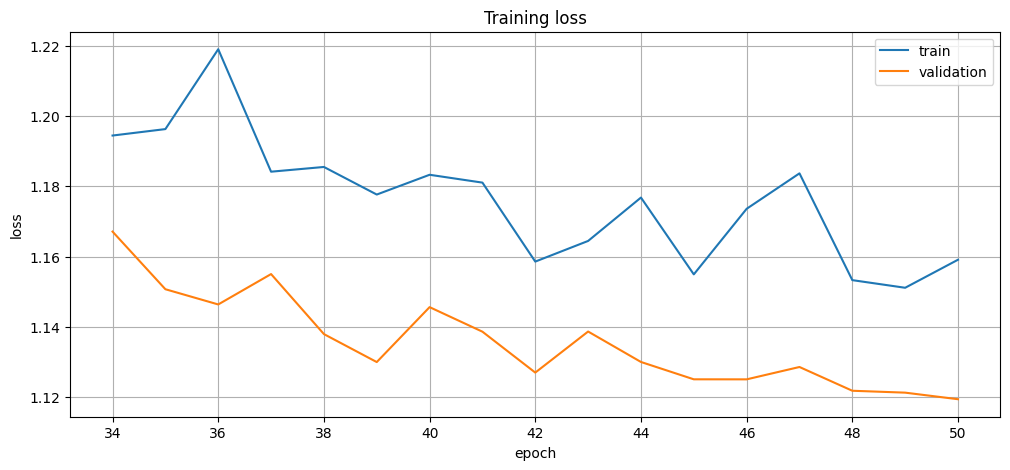

In [21]:
epochs = [
    row["epoch"]
    for row in history
]

train_losses = [
    row["train_loss"]
    for row in history
]

val_losses = [
    row["val_loss"]
    for row in history
]


plt.figure(
    figsize=(12, 5)
)

plt.plot(
    epochs,
    train_losses,
    label="train",
)

plt.plot(
    epochs,
    val_losses,
    label="validation",
)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid(True)
plt.legend()
plt.show()

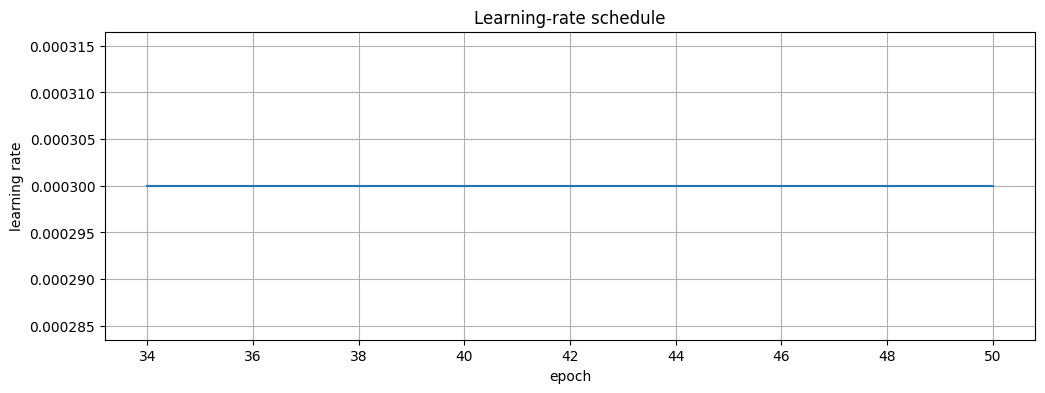

In [22]:
learning_rates = [
    row["learning_rate"]
    for row in history
]

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    epochs,
    learning_rates,
)

plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.title("Learning-rate schedule")
plt.grid(True)
plt.show()

In [23]:
best_checkpoint = load_training_checkpoint(
    BEST_CHECKPOINT_PATH,
    model=model,
    map_location=DEVICE,
    restore_rng_state=False,
)


test_augmentation_generator = make_augmentation_generator(
    TEST_AUGMENTATION_SEED
)


test_metrics, _ = run_epoch(
    test_loader,
    training=False,
    augmentation_generator=test_augmentation_generator,
)


print("Test metrics:")

for key, value in sorted(
    test_metrics.items()
):
    print(
        f"{key}: {value}"
    )

Test metrics:
epoch_time_s: 199.47552365704905
imu/change_time_error_s: 0.5283162004190454
imu/event_accuracy: 0.4678111591393685
imu/loss_change_event: 0.693669247610204
imu/loss_change_time: 0.008777493918754256
imu/loss_rotation: 0.3370567656126145
imu/loss_time_offset: 0.02592002688900425
imu/loss_translation: 0.3929510713902666
imu/rotation_error_deg: 6.55252211015453
imu/time_offset_error_ms: 2.24588169628629
imu/translation_error_cm: 7.083403493201784
lidar/change_time_error_s: 0.5098066395614962
lidar/event_accuracy: 0.5250357656349269
lidar/loss_change_event: 0.6929227743026013
lidar/loss_change_time: 0.008439313962746503
lidar/loss_rotation: 0.32348498096622963
lidar/loss_time_offset: 0.016953608438170092
lidar/loss_translation: 0.3825706068282475
lidar/rotation_error_deg: 6.355175456946159
lidar/time_offset_error_ms: 1.6326467066534258
lidar/translation_error_cm: 6.935109448194162
loss_total: 1.1399298508961995
samples_per_s: 3.5041893220030595


In [24]:
from obscalib.data.collation import collate_windows
from obscalib.geometry.lie import se3_log

In [25]:
##################################################
# Prediction visualization configuration
##################################################

VIS_SEQUENCE_NAME = "Urban38"

# Offset within this sequence's WindowSample list.
VIS_START_WINDOW = 0

# Number of consecutive windows to evaluate and plot.
VIS_NUM_WINDOWS = 80

# Evaluation batch size.
VIS_BATCH_SIZE = 16

# Separate deterministic augmentation realization for visualization.
VIS_AUGMENTATION_SEED = 56789

In [26]:
sequence_indices = [
    index
    for index in range(len(test_dataset))
    if test_dataset.sequence_name_for_window(index) == VIS_SEQUENCE_NAME
]

if not sequence_indices:
    raise ValueError(
        f"Sequence {VIS_SEQUENCE_NAME!r} is not present in test_dataset."
    )

selected_indices = sequence_indices[
    VIS_START_WINDOW : VIS_START_WINDOW + VIS_NUM_WINDOWS
]

if not selected_indices:
    raise ValueError(
        "Selected visualization window range is empty."
    )

print("Sequence:", VIS_SEQUENCE_NAME)
print("Selected windows:", len(selected_indices))
print(
    "Dataset indices:",
    selected_indices[0],
    "...",
    selected_indices[-1],
)

Sequence: Urban38
Selected windows: 80
Dataset indices: 0 ... 79


In [27]:
def collect_calibration_predictions(dataset, indices, *, batch_size, augmentation_seed):
    """Run selected dataset windows and collect initial, reference, and predicted calibration corrections."""

    model.eval()

    augmentation_generator = make_augmentation_generator(
        augmentation_seed
    )

    collected = {
        calibration_key: {
            "reference_delta_xi": [],
            "predicted_delta_xi": [],
            "reference_delta_tau": [],
            "predicted_delta_tau": [],
            "event_label": [],
            "event_probability": [],
            "reference_change_time": [],
            "predicted_change_time": [],
        }
        for calibration_key in model_config.head_keys
    }

    with torch.no_grad():
        for start in range(
            0,
            len(indices),
            batch_size,
        ):
            batch_indices = indices[
                start : start + batch_size
            ]

            base_window = collate_windows(
                [
                    dataset[index]
                    for index in batch_indices
                ]
            )

            base_window = window_batch_to(
                base_window,
                DEVICE,
                dtype=MODEL_DTYPE,
            )

            augmentation_result = augmentation_pipeline(
                base_window,
                generator=augmentation_generator,
            )

            augmented_window = (
                augmentation_result.augmented_window
            )

            step_result = window_step(
                augmented_window
            )

            for calibration_key, prediction in step_result.model_output.predictions.items():
                target = augmented_window.targets[
                    calibration_key
                ]

                current_state = augmented_window.current_calibration[
                    calibration_key
                ]

                ##################################################
                # Reference correction used by training loss
                ##################################################

                reference_delta_transform = (
                    target.next_transform
                    @ torch.linalg.inv(
                        current_state.transform
                    )
                )

                reference_delta_xi = se3_log(
                    reference_delta_transform
                )

                reference_delta_tau = (
                    target.next_time_offset
                    - current_state.time_offset
                )

                ##################################################
                # Collect reference and model prediction
                ##################################################

                collected[calibration_key]["reference_delta_xi"].append(
                    reference_delta_xi.cpu()
                )

                collected[calibration_key]["predicted_delta_xi"].append(
                    prediction.delta_xi.cpu()
                )

                collected[calibration_key]["reference_delta_tau"].append(
                    reference_delta_tau.cpu()
                )

                collected[calibration_key]["predicted_delta_tau"].append(
                    prediction.delta_tau.cpu()
                )

                collected[calibration_key]["event_label"].append(
                    target.change_label.cpu()
                )

                collected[calibration_key]["event_probability"].append(
                    torch.sigmoid(
                        prediction.change_event_logit
                    ).cpu()
                )

                collected[calibration_key]["reference_change_time"].append(
                    target.change_time.cpu()
                )

                collected[calibration_key]["predicted_change_time"].append(
                    prediction.change_time.cpu()
                )

    ##################################################
    # Concatenate batches
    ##################################################

    for calibration_key in collected:
        for field_name in collected[calibration_key]:
            collected[calibration_key][field_name] = torch.cat(
                collected[calibration_key][field_name],
                dim=0,
            ).numpy()

    return collected


visualization_results = collect_calibration_predictions(
    test_dataset,
    selected_indices,
    batch_size=VIS_BATCH_SIZE,
    augmentation_seed=VIS_AUGMENTATION_SEED,
)

In [28]:
CALIBRATION_COMPONENT_NAMES = (
    "phi_x",
    "phi_y",
    "phi_z",
    "rho_x",
    "rho_y",
    "rho_z",
)


def plot_calibration_corrections(results, calibration_key, window_stride_s):
    """Plot reference and predicted correction relative to the initial supplied calibration."""

    result = results[
        calibration_key
    ]

    reference_xi = result[
        "reference_delta_xi"
    ]

    predicted_xi = result[
        "predicted_delta_xi"
    ]

    reference_tau = result[
        "reference_delta_tau"
    ][:, 0]

    predicted_tau = result[
        "predicted_delta_tau"
    ][:, 0]

    times_s = (
        np.arange(
            len(reference_xi)
        )
        * window_stride_s
    )

    fig, axes = plt.subplots(
        7,
        1,
        figsize=(15, 16),
        sharex=True,
    )

    ##################################################
    # Rotation correction
    ##################################################

    for component_index in range(3):
        axes[component_index].plot(
            times_s,
            np.zeros_like(times_s),
            label="initial",
        )

        axes[component_index].plot(
            times_s,
            np.rad2deg(
                reference_xi[
                    :,
                    component_index,
                ]
            ),
            label="reference",
        )

        axes[component_index].plot(
            times_s,
            np.rad2deg(
                predicted_xi[
                    :,
                    component_index,
                ]
            ),
            label="predicted",
        )

        axes[component_index].set_ylabel(
            f"{CALIBRATION_COMPONENT_NAMES[component_index]} [deg]"
        )

        axes[component_index].grid(
            True
        )

        axes[component_index].legend()

    ##################################################
    # Translational SE3 tangent correction
    ##################################################

    for component_index in range(
        3,
        6,
    ):
        axes[component_index].plot(
            times_s,
            np.zeros_like(times_s),
            label="initial",
        )

        axes[component_index].plot(
            times_s,
            100.0
            * reference_xi[
                :,
                component_index,
            ],
            label="reference",
        )

        axes[component_index].plot(
            times_s,
            100.0
            * predicted_xi[
                :,
                component_index,
            ],
            label="predicted",
        )

        axes[component_index].set_ylabel(
            f"{CALIBRATION_COMPONENT_NAMES[component_index]} [cm]"
        )

        axes[component_index].grid(
            True
        )

        axes[component_index].legend()

    ##################################################
    # Temporal correction
    ##################################################

    axes[6].plot(
        times_s,
        np.zeros_like(times_s),
        label="initial",
    )

    axes[6].plot(
        times_s,
        1000.0 * reference_tau,
        label="reference",
    )

    axes[6].plot(
        times_s,
        1000.0 * predicted_tau,
        label="predicted",
    )

    axes[6].set_ylabel(
        "delta_tau [ms]"
    )

    axes[6].set_xlabel(
        "time across selected windows [s]"
    )

    axes[6].grid(
        True
    )

    axes[6].legend()

    fig.suptitle(
        f"{calibration_key}: calibration correction prediction"
    )

    fig.tight_layout()
    plt.show()

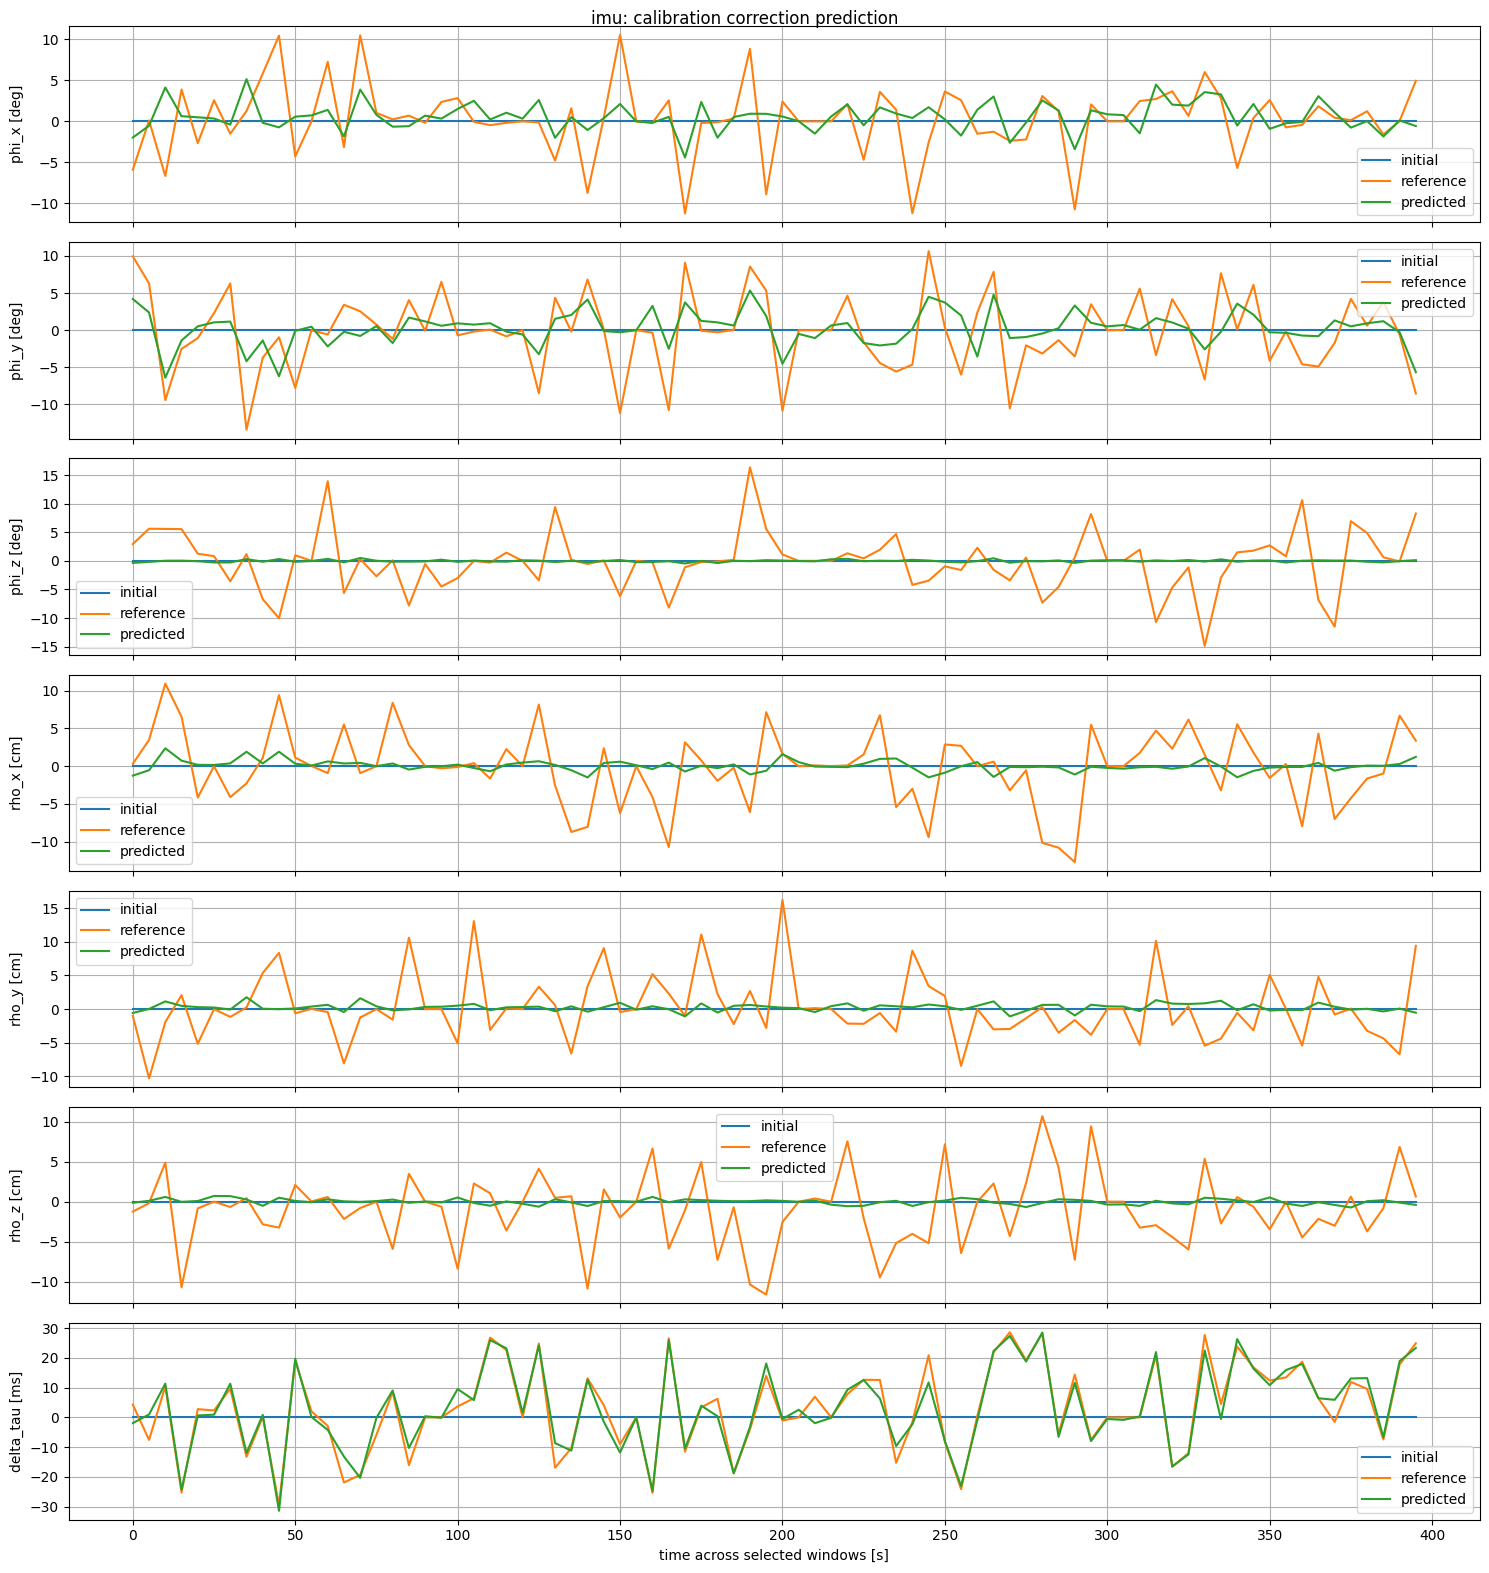

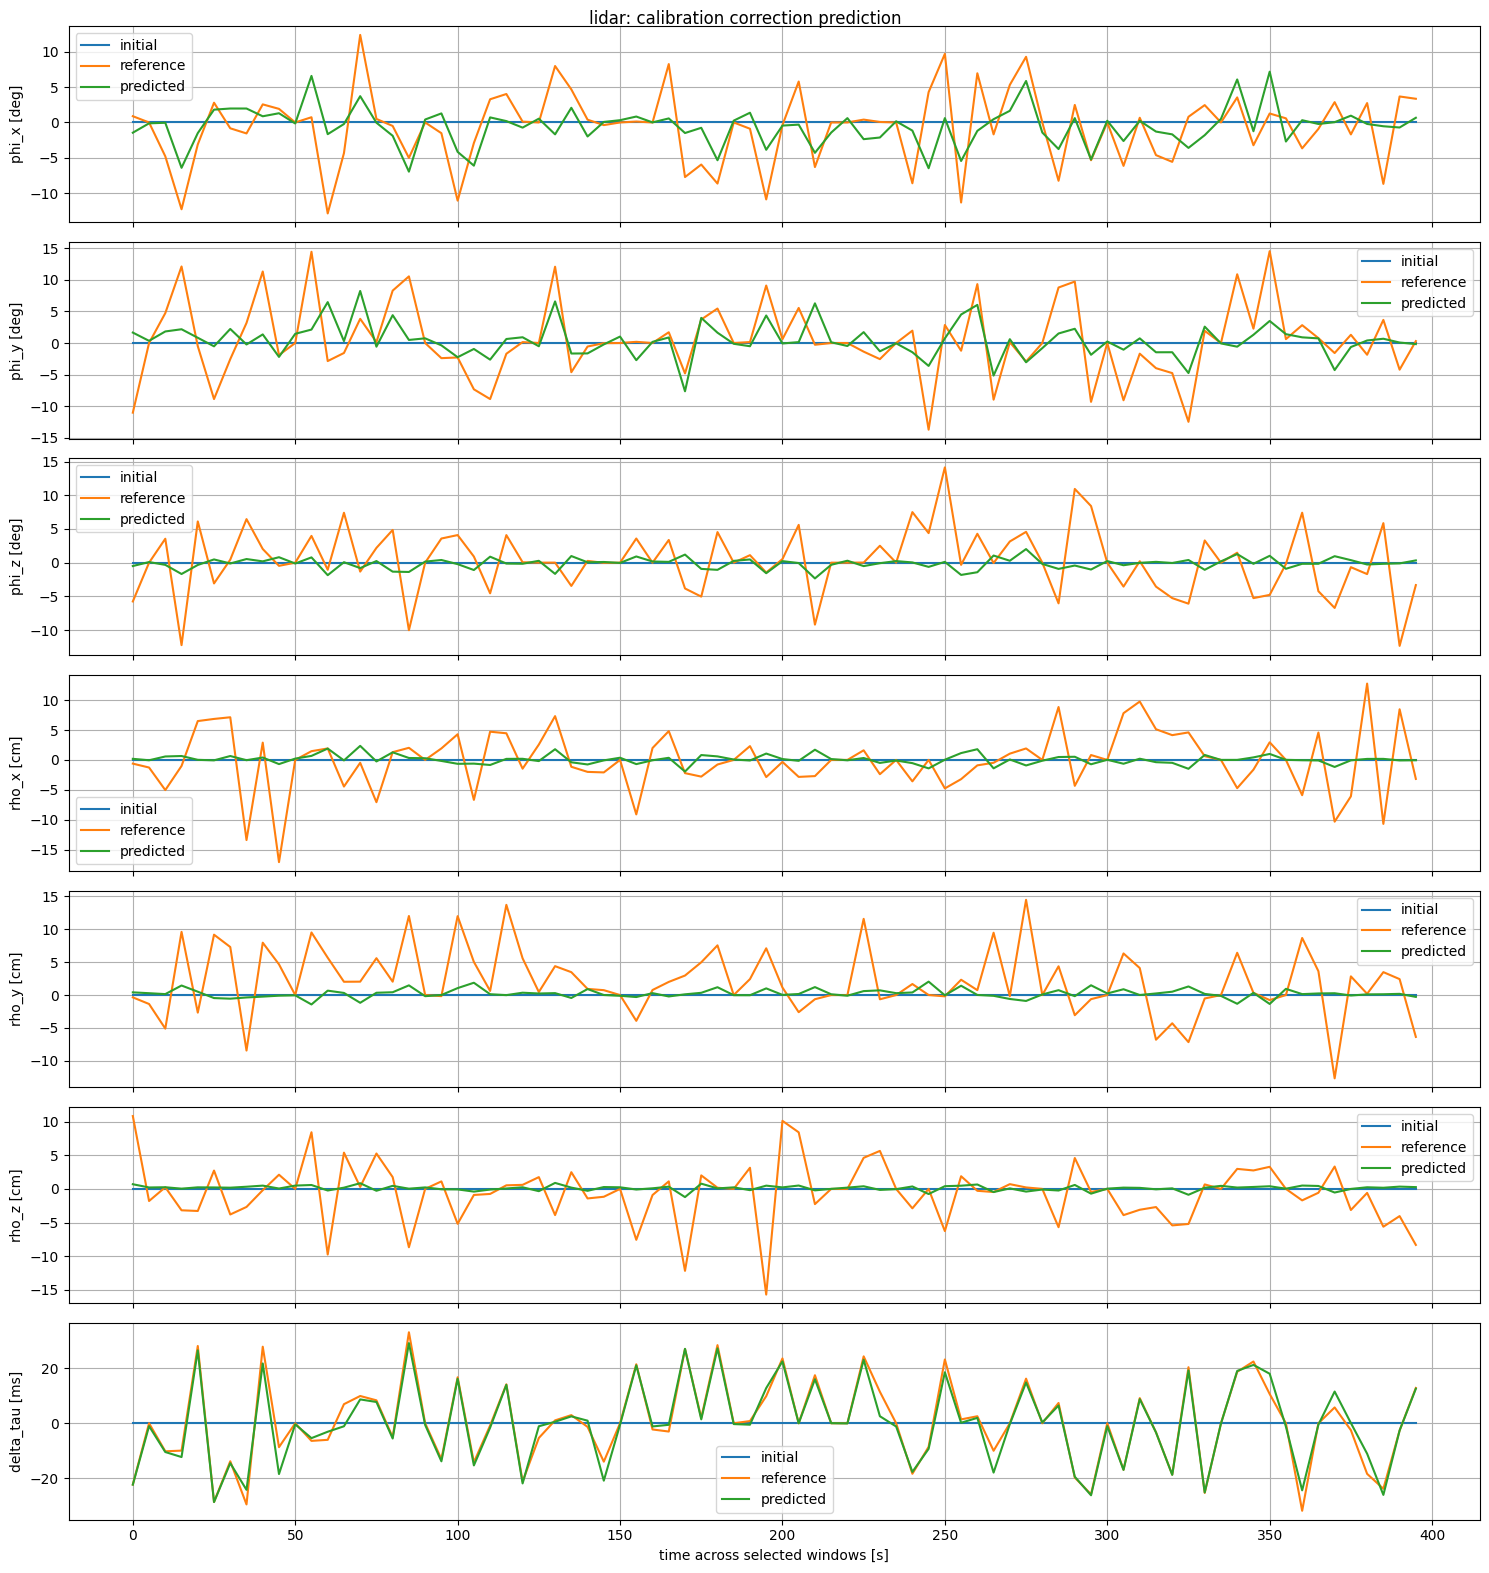

In [29]:
plot_calibration_corrections(
    visualization_results,
    "imu",
    WINDOW_STRIDE_S,
)

plot_calibration_corrections(
    visualization_results,
    "lidar",
    WINDOW_STRIDE_S,
)

In [30]:
def plot_correction_magnitudes(results, calibration_key, window_stride_s):
    """Plot scalar spatial and temporal correction magnitudes."""

    result = results[
        calibration_key
    ]

    reference_xi = result[
        "reference_delta_xi"
    ]

    predicted_xi = result[
        "predicted_delta_xi"
    ]

    reference_tau = result[
        "reference_delta_tau"
    ][:, 0]

    predicted_tau = result[
        "predicted_delta_tau"
    ][:, 0]

    times_s = (
        np.arange(
            len(reference_xi)
        )
        * window_stride_s
    )

    reference_rotation_deg = np.rad2deg(
        np.linalg.norm(
            reference_xi[:, :3],
            axis=1,
        )
    )

    predicted_rotation_deg = np.rad2deg(
        np.linalg.norm(
            predicted_xi[:, :3],
            axis=1,
        )
    )

    reference_translation_cm = (
        100.0
        * np.linalg.norm(
            reference_xi[:, 3:],
            axis=1,
        )
    )

    predicted_translation_cm = (
        100.0
        * np.linalg.norm(
            predicted_xi[:, 3:],
            axis=1,
        )
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15, 9),
        sharex=True,
    )

    axes[0].plot(
        times_s,
        reference_rotation_deg,
        label="reference",
    )

    axes[0].plot(
        times_s,
        predicted_rotation_deg,
        label="predicted",
    )

    axes[0].axhline(
        0.0,
        label="initial",
    )

    axes[0].set_ylabel(
        "rotation [deg]"
    )

    axes[0].grid(
        True
    )

    axes[0].legend()

    axes[1].plot(
        times_s,
        reference_translation_cm,
        label="reference",
    )

    axes[1].plot(
        times_s,
        predicted_translation_cm,
        label="predicted",
    )

    axes[1].axhline(
        0.0,
        label="initial",
    )

    axes[1].set_ylabel(
        "rho norm [cm]"
    )

    axes[1].grid(
        True
    )

    axes[1].legend()

    axes[2].plot(
        times_s,
        1000.0 * reference_tau,
        label="reference",
    )

    axes[2].plot(
        times_s,
        1000.0 * predicted_tau,
        label="predicted",
    )

    axes[2].axhline(
        0.0,
        label="initial",
    )

    axes[2].set_ylabel(
        "delta_tau [ms]"
    )

    axes[2].set_xlabel(
        "time across selected windows [s]"
    )

    axes[2].grid(
        True
    )

    axes[2].legend()

    fig.suptitle(
        f"{calibration_key}: correction magnitudes"
    )

    fig.tight_layout()
    plt.show()

In [31]:
def plot_event_predictions(results, calibration_key, window_stride_s):
    """Plot true calibration events, predicted probabilities, and event times."""

    result = results[
        calibration_key
    ]

    event_label = result[
        "event_label"
    ][:, 0]

    event_probability = result[
        "event_probability"
    ][:, 0]

    reference_change_time = result[
        "reference_change_time"
    ][:, 0]

    predicted_change_time = result[
        "predicted_change_time"
    ][:, 0]

    times_s = (
        np.arange(
            len(event_label)
        )
        * window_stride_s
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(15, 7),
        sharex=True,
    )

    ##################################################
    # Event classification
    ##################################################

    axes[0].step(
        times_s,
        event_label,
        where="mid",
        label="true event",
    )

    axes[0].plot(
        times_s,
        event_probability,
        label="predicted probability",
    )

    axes[0].axhline(
        0.5,
        linestyle="--",
        label="classification threshold",
    )

    axes[0].set_ylim(
        -0.05,
        1.05,
    )

    axes[0].set_ylabel(
        "event"
    )

    axes[0].grid(
        True
    )

    axes[0].legend()

    ##################################################
    # Change-time prediction for actual events only
    ##################################################

    event_mask = (
        event_label
        > 0.5
    )

    axes[1].plot(
        times_s[event_mask],
        reference_change_time[event_mask],
        marker="o",
        label="reference change time",
    )

    axes[1].plot(
        times_s[event_mask],
        predicted_change_time[event_mask],
        marker="o",
        label="predicted change time",
    )

    axes[1].set_ylabel(
        "time within window [s]"
    )

    axes[1].set_xlabel(
        "time across selected windows [s]"
    )

    axes[1].grid(
        True
    )

    axes[1].legend()

    fig.suptitle(
        f"{calibration_key}: calibration-event prediction"
    )

    fig.tight_layout()
    plt.show()

In [32]:
def print_initial_vs_model_errors(results, calibration_key):
    """Compare the trained model against a zero-correction baseline."""

    result = results[
        calibration_key
    ]

    reference_xi = result[
        "reference_delta_xi"
    ]

    predicted_xi = result[
        "predicted_delta_xi"
    ]

    reference_tau = result[
        "reference_delta_tau"
    ][:, 0]

    predicted_tau = result[
        "predicted_delta_tau"
    ][:, 0]

    ##################################################
    # Initial calibration means predicted correction = 0
    ##################################################

    initial_rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            reference_xi[:, :3],
            axis=1,
        )
    )

    model_rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            predicted_xi[:, :3]
            - reference_xi[:, :3],
            axis=1,
        )
    )

    initial_translation_error_cm = (
        100.0
        * np.linalg.norm(
            reference_xi[:, 3:],
            axis=1,
        )
    )

    model_translation_error_cm = (
        100.0
        * np.linalg.norm(
            predicted_xi[:, 3:]
            - reference_xi[:, 3:],
            axis=1,
        )
    )

    initial_tau_error_ms = (
        1000.0
        * np.abs(
            reference_tau
        )
    )

    model_tau_error_ms = (
        1000.0
        * np.abs(
            predicted_tau
            - reference_tau
        )
    )

    print(calibration_key)
    print()

    print(
        f"rotation:    initial={initial_rotation_error_deg.mean():.3f} deg, "
        f"model={model_rotation_error_deg.mean():.3f} deg"
    )

    print(
        f"translation: initial={initial_translation_error_cm.mean():.3f} cm, "
        f"model={model_translation_error_cm.mean():.3f} cm"
    )

    print(
        f"time offset: initial={initial_tau_error_ms.mean():.3f} ms, "
        f"model={model_tau_error_ms.mean():.3f} ms"
    )

In [33]:
def print_prediction_collapse_diagnostics(results, calibration_key):
    result = results[
        calibration_key
    ]

    reference_xi = result[
        "reference_delta_xi"
    ]

    predicted_xi = result[
        "predicted_delta_xi"
    ]

    names = (
        "phi_x",
        "phi_y",
        "phi_z",
        "rho_x",
        "rho_y",
        "rho_z",
    )

    print(
        calibration_key
    )

    print()

    for index, name in enumerate(
        names
    ):
        target = reference_xi[
            :,
            index,
        ]

        prediction = predicted_xi[
            :,
            index,
        ]

        if np.std(target) > 0.0 and np.std(prediction) > 0.0:
            correlation = np.corrcoef(
                target,
                prediction,
            )[0, 1]
        else:
            correlation = np.nan

        print(
            f"{name:5s}  "
            f"target std={np.std(target):.5f}  "
            f"pred std={np.std(prediction):.5f}  "
            f"corr={correlation:+.3f}"
        )


print_prediction_collapse_diagnostics(
    visualization_results,
    "imu",
)

print()

print_prediction_collapse_diagnostics(
    visualization_results,
    "lidar",
)

imu

phi_x  target std=0.07437  pred std=0.03020  corr=+0.396
phi_y  target std=0.08999  pred std=0.04039  corr=+0.662
phi_z  target std=0.09013  pred std=0.00331  corr=+0.020
rho_x  target std=0.04828  pred std=0.00720  corr=+0.352
rho_y  target std=0.04868  pred std=0.00551  corr=+0.089
rho_z  target std=0.04471  pred std=0.00333  corr=+0.008

lidar

phi_x  target std=0.08836  pred std=0.04697  corr=+0.534
phi_y  target std=0.10173  pred std=0.04579  corr=+0.554
phi_z  target std=0.08280  pred std=0.01385  corr=+0.118
rho_x  target std=0.05047  pred std=0.00756  corr=+0.122
rho_y  target std=0.04977  pred std=0.00662  corr=+0.011
rho_z  target std=0.04425  pred std=0.00376  corr=+0.246
